In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Change the trending date to datetime and possibly publish_time

In [3]:
us_df = pd.read_csv("USvideos.csv")
us_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [4]:
us_df['trending_date']=pd.to_datetime(us_df['trending_date'], format="%y.%d.%m"
) # Here we are changing the trending date column using to_datetime and changing the date order to y-m-d
us_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                40949 non-null  object        
 1   trending_date           40949 non-null  datetime64[ns]
 2   title                   40949 non-null  object        
 3   channel_title           40949 non-null  object        
 4   category_id             40949 non-null  int64         
 5   publish_time            40949 non-null  object        
 6   tags                    40949 non-null  object        
 7   views                   40949 non-null  int64         
 8   likes                   40949 non-null  int64         
 9   dislikes                40949 non-null  int64         
 10  comment_count           40949 non-null  int64         
 11  thumbnail_link          40949 non-null  object        
 12  comments_disabled       40949 non-null  bool  

In [5]:
us_df.head() #Checking to see if the trending date changed appropriately

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [6]:
us_df['publish_time']=pd.to_datetime(us_df['publish_time'], format='%Y-%m-%dT%H:%M:%S.%fZ'
)
us_df.head() # This cell transforms publish_time to_datetime including hours,minutes,seconds (T)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [7]:
#us_df["publish_time"] = (
    #pd.to_datetime(us_df["publish_time"])
      #.dt.date
#)
#us_df.head()
# This cell commented out due to it getting rid of the T portion of the column. Cell above keeps T

## Notes/Ideas

Popularity = group by trending date (and possibly category) and then use value counts to plot on line graph to see how many videos at that date were trending (check to see later if for example music and political videos are both driven up by "controversy") (may not be required)  
popularity ratio = proportion of likes and dislikes per video  
engagement could be ratio of views to number of likes and dislikes on the video  
neutral = viewed but did not like or dislike

In [8]:
us_df["total_thumbs"]= us_df['likes'] + us_df['dislikes'] # total thumbs gives us total likes and dislikes
us_df.head(1)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,60493


In [9]:
#Proportion of viewers who chose like instead of dislike
us_df['like_ratio']= us_df["likes"] / us_df["total_thumbs"]


In [10]:
#Proportion of individuals who chose dislike (not like)
us_df['dislike_ratio']= us_df["dislikes"] / us_df["total_thumbs"]
us_df.head(4)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs,like_ratio,dislike_ratio
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,60493,0.950970,0.049030
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",103331,0.940521,0.059479
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,151372,0.964729,0.035271
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,10838,0.938550,0.061450


In [11]:
# This shows how many people viewed but did not like or dislike
us_df["view_to_rate_prop"] = (((us_df["views"] - (us_df["likes"] + us_df["dislikes"])) / us_df["views"]))
us_df.head(1)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs,like_ratio,dislike_ratio,view_to_rate_prop
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,60493,0.95097,0.04903,0.919167


In [14]:
ca_df = pd.read_csv("CAvideos.csv")
ca_df.head(1)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...


### Dictionary below defining original data set categories to their associated genre.

In [15]:
youtube_categories = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    18: "Short Movies",
    19: "Travel & Events",
    20: "Gaming",
    21: "Videoblogging",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    27: "Education",
    28: "Science & Technology",
    29: "Nonprofits & Activism",
    30: "Movies",
    31: "Anime/Animation",
    32: "Action/Adventure",
    33: "Classics",
    34: "Comedy",
    35: "Documentary",
    36: "Drama",
    37: "Family",
    38: "Foreign",
    39: "Horror",
    40: "Sci-Fi/Fantasy",
    41: "Thriller",
    42: "Shorts",
    43: "Shows",
    44: "Trailers"
}

### Canada adding category genres to IDs

In [16]:
ca_df["youtube_category_name"] = ca_df["category_id"].map(youtube_categories)

### US adding category genres to IDs

In [17]:
us_df["youtube_category_name"] = us_df["category_id"].map(youtube_categories)

### US top views by category name

In [18]:
us_df.groupby("youtube_category_name")[["views", "likes", "dislikes"]].sum().sort_values("views", ascending=False)

,views,likes,dislikes
youtube_category_name,,,
Music,40132892190,1416838584,51179008
Entertainment,20604388195,530516491,42987663
Film & Animation,7284156721,165997476,6075148
Comedy,5117426208,216346746,7230391
People & Blogs,4917191726,186615999,10187901
Sports,4404456673,98621211,5133551
Howto & Style,4078545064,162880075,5473899
Science & Technology,3487756816,82532638,4548402
Gaming,2141218625,69038284,9184466


### Canada top views by category name
Looked at the relationship between Canada and US to get a general idea of how the two countries compare. May elaborate more after initial US analysis.

In [19]:
ca_df.groupby("youtube_category_name")[["views", "likes", "dislikes"]].sum().sort_values("views", ascending=False)

,views,likes,dislikes
youtube_category_name,,,
Entertainment,13671215509,387245433,25791583
Music,13179850194,564447530,22098190
Comedy,3708438785,196046674,5372515
People & Blogs,3228227926,105388564,9480796
Sports,2997652188,59449419,3286369
Film & Animation,2939060844,77802003,3111259
News & Politics,1614610043,32705054,3264041
Howto & Style,1570846611,51183104,1730520
Science & Technology,1425090421,42814598,1791153


In [20]:
us_df.sample(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs,like_ratio,dislike_ratio,view_to_rate_prop,youtube_category_name
34200,iGD4bBgWPcY,2018-05-12,[BEHIND THE SCENES] Havana – Pentatonix,PTXofficial,10,2018-05-08 14:02:11,"Pentatonix|""Penatonix""|""PTX""|""PTXofficial""|""Mi...",455317,17194,433,...,https://i.ytimg.com/vi/iGD4bBgWPcY/default.jpg,False,False,False,"PTX PRESENTS: TOP POP, VOL. I OUT NOW FEATURIN...",17627,0.975435,0.024565,0.961286,Music
32654,jpH-8HiMCRI,2018-05-04,Deep Fried Ice Cream & Cookie Dough & Funfetti...,Clevver Style,26,2018-04-27 15:00:06,"food|""deep fried desserts""|""fried ice cream""|""...",357058,15747,295,...,https://i.ytimg.com/vi/jpH-8HiMCRI/default.jpg,False,False,False,"Deep fried ice cream, funfetti cake mix, or co...",16042,0.981611,0.018389,0.955072,Howto & Style
3219,0nybdPCuvRI,2017-11-30,LeBron James ejected for first time in career ...,ESPN,17,2017-11-29 02:16:58,"lebron|""james""|""ejected""|""first""|""time""|""caree...",276279,1761,121,...,https://i.ytimg.com/vi/0nybdPCuvRI/default.jpg,False,False,False,LeBron James is tossed from the game after arg...,1882,0.935707,0.064293,0.993188,Sports
15907,6Nr_xHolP1Q,2018-02-03,EVERY ELEVATOR EVER,Smosh,23,2018-01-29 17:00:00,"elevator|""every blank ever""|""smosh""|""every eve...",1596587,51575,2094,...,https://i.ytimg.com/vi/6Nr_xHolP1Q/default.jpg,False,False,False,"Elevators - whether it's awkward small talk, o...",53669,0.960983,0.039017,0.966385,Comedy
15155,52L2HML5O1k,2018-01-30,The Last Jedi Novelization to Feature Deleted ...,Star Wars,24,2018-01-24 20:00:01,"The Star Wars Show|""Star Wars Show""|""Andi Guti...",314621,4961,351,...,https://i.ytimg.com/vi/52L2HML5O1k/default.jpg,False,False,False,"In this installment of The Star Wars Show, dir...",5312,0.933923,0.066077,0.983116,Entertainment


In [21]:
us_df.head(5)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs,like_ratio,dislike_ratio,view_to_rate_prop,youtube_category_name
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,...,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,60493,0.950970,0.049030,0.919167,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",103331,0.940521,0.059479,0.957280,Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,151372,0.964729,0.035271,0.952569,Comedy
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,10838,0.938550,0.061450,0.968418,Entertainment
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,134224,0.985181,0.014819,0.935954,Entertainment


In [22]:
us_df[us_df.duplicated()].shape

(48, 21)

### Duplicates found, need to remove

In [23]:
duplicates = us_df[us_df.duplicated(keep=False)]
duplicates.sort_values("views")

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,total_thumbs,like_ratio,dislike_ratio,view_to_rate_prop,youtube_category_name
34923,D2mxKEa2xmA,2018-05-15,10 Most DEVASTATING Cyber Attacks in History,MatthewSantoro,24,2018-05-13 13:00:01,"computer hacks|""cyber attack""|""computer virus""...",158406,6773,364,...,https://i.ytimg.com/vi/D2mxKEa2xmA/default.jpg,False,False,False,"Download the best VPN on the market, NORDVPN n...",7137,0.948998,0.051002,0.954945,Entertainment
34774,D2mxKEa2xmA,2018-05-15,10 Most DEVASTATING Cyber Attacks in History,MatthewSantoro,24,2018-05-13 13:00:01,"computer hacks|""cyber attack""|""computer virus""...",158406,6773,364,...,https://i.ytimg.com/vi/D2mxKEa2xmA/default.jpg,False,False,False,"Download the best VPN on the market, NORDVPN n...",7137,0.948998,0.051002,0.954945,Entertainment
34945,zcEE8J2Bqa8,2018-05-15,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11 18:27:01,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,...,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,20712,0.993241,0.006759,0.874940,Comedy
34796,zcEE8J2Bqa8,2018-05-15,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11 18:27:01,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,...,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,20712,0.993241,0.006759,0.874940,Comedy
34768,1U1u5aKU3AY,2018-05-15,New lava fissures fuel fears of eruption in Ha...,CNN,25,2018-05-13 19:30:53,"latest News|""Happening Now""|""CNN""|""lava""|""hawa...",241387,1488,251,...,https://i.ytimg.com/vi/1U1u5aKU3AY/default.jpg,False,False,False,Three new fissures have opened on Hawaii's Big...,1739,0.855664,0.144336,0.992796,News & Politics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34927,UfKmSfgFxi8,2018-05-15,FORTNITE The Movie (Official Fake Trailer),nigahiga,24,2018-05-11 21:11:16,"ryan|""higa""|""higatv""|""nigahiga""|""fortnite""|""th...",8289563,408385,10966,...,https://i.ytimg.com/vi/UfKmSfgFxi8/default.jpg,False,False,False,Play Fortnite for FREE here: https://pixly.go2...,419351,0.973850,0.026150,0.949412,Entertainment
34794,oSEeK9yDNQI,2018-05-15,Clash Royale: Meet the Rascals! (New Card!),Clash Royale,20,2018-05-10 13:19:23,"Clash Royale|""Clash Royale Game""|""Supercell""|""...",13418844,258720,22805,...,https://i.ytimg.com/vi/oSEeK9yDNQI/default.jpg,False,False,False,Rascals! What have they done now...New Card Ou...,281525,0.918995,0.081005,0.979020,Gaming
34943,oSEeK9yDNQI,2018-05-15,Clash Royale: Meet the Rascals! (New Card!),Clash Royale,20,2018-05-10 13:19:23,"Clash Royale|""Clash Royale Game""|""Supercell""|""...",13418844,258720,22805,...,https://i.ytimg.com/vi/oSEeK9yDNQI/default.jpg,False,False,False,Rascals! What have they done now...New Card Ou...,281525,0.918995,0.081005,0.979020,Gaming
34941,uxbQATBAXf8,2018-05-15,Deadpool 2 | With Apologies to David Beckham,20th Century Fox,1,2018-05-10 14:24:29,"Trailer|""Deadpool""|""20th Century Fox (Producti...",15960127,374825,3823,...,https://i.ytimg.com/vi/uxbQATBAXf8/default.jpg,False,False,False,Get your Deadpool 2 tickets at http://www.Dead...,378648,0.989904,0.010096,0.976275,Film & Animation


### look to see how correlation between dislikes may drive views

In [24]:
views_category= us_df.groupby('youtube_category_name').size().sort_values(ascending=False)
views_category

youtube_category_name
Entertainment            9964
Music                    6472
Howto & Style            4146
Comedy                   3457
People & Blogs           3210
News & Politics          2487
Science & Technology     2401
Film & Animation         2345
Sports                   2174
Education                1656
Pets & Animals            920
Gaming                    817
Travel & Events           402
Autos & Vehicles          384
Nonprofits & Activism      57
Shows                      57
dtype: int64

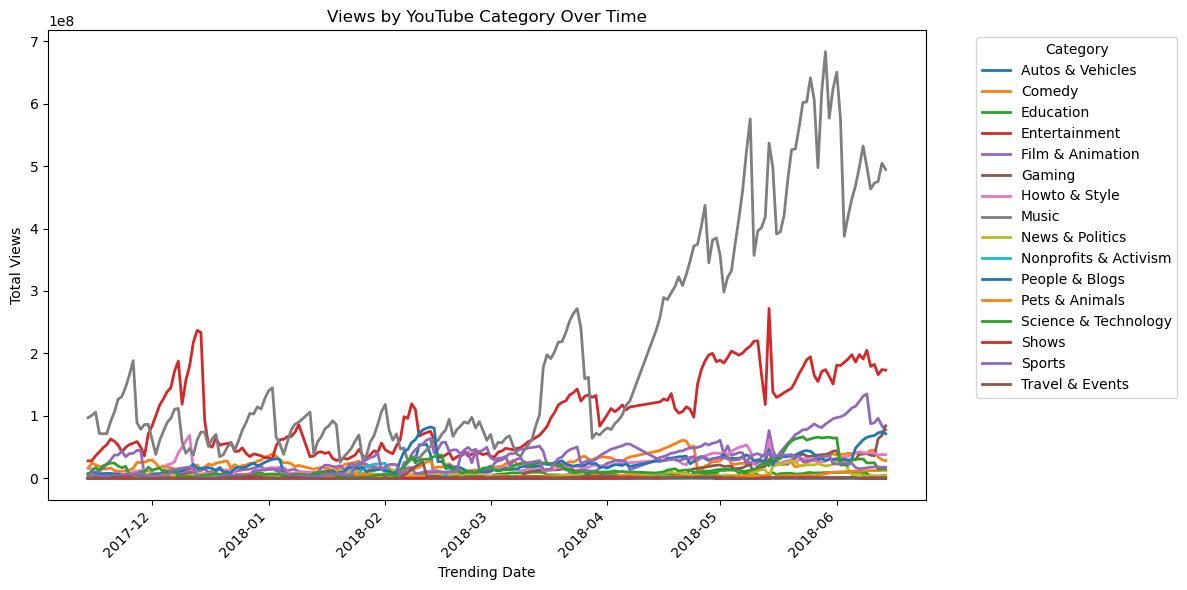

In [ ]:
# What is the most trending category at a certain point in time

category_views = (
    us_df.groupby(["trending_date", "youtube_category_name"])["views"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

category_views.plot(
    kind="line",
    figsize=(12, 6),
    linewidth=2
)

plt.title("Views by YouTube Category Over Time")
plt.xlabel("Trending Date")
plt.ylabel("Total Views")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

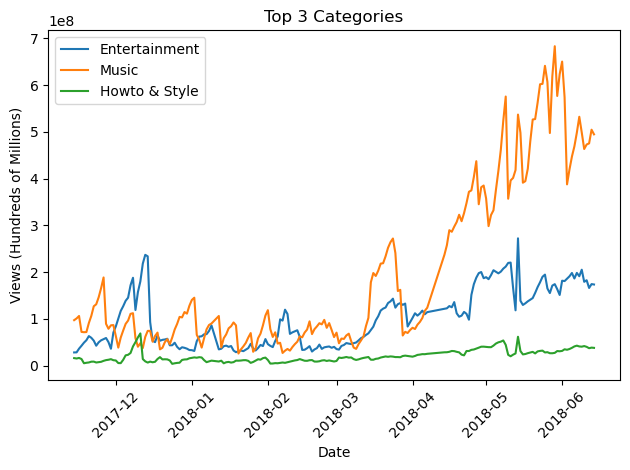

In [48]:
# What is the most trending category at a certain point in time

category_views = us_df.groupby(['youtube_category_name', 'trending_date'])['views'].sum()
entertainment_views = category_views['Entertainment']
music_views = category_views['Music']
howto_style_views = category_views['Howto & Style']

plt.plot(entertainment_views.index, entertainment_views.values, label="Entertainment")
plt.plot(music_views.index, music_views.values, label="Music")
plt.plot(howto_style_views.index, howto_style_views.values, label="Howto & Style")


plt.title("Top 3 Categories")
plt.xlabel("Date")
plt.ylabel("Views (Hundreds of Millions)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

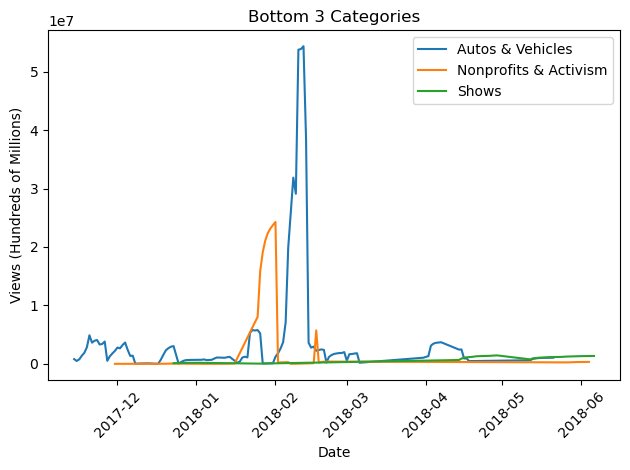

In [ ]:
# What is the least trending category at a certain point in time

category_views = us_df.groupby(['youtube_category_name', 'trending_date'])['views'].sum()
auto_views = category_views['Autos & Vehicles']
nonprofit_views = category_views['Nonprofits & Activism']
shows_views = category_views['Shows']

plt.plot(auto_views.index, auto_views.values, label="Autos & Vehicles")
plt.plot(nonprofit_views.index, nonprofit_views.values, label="Nonprofits & Activism")
plt.plot(shows_views.index, shows_views.values, label="Shows")


plt.title("Bottom 3 Categories")
plt.xlabel("Date")
plt.ylabel("Views (Hundreds of Millions)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

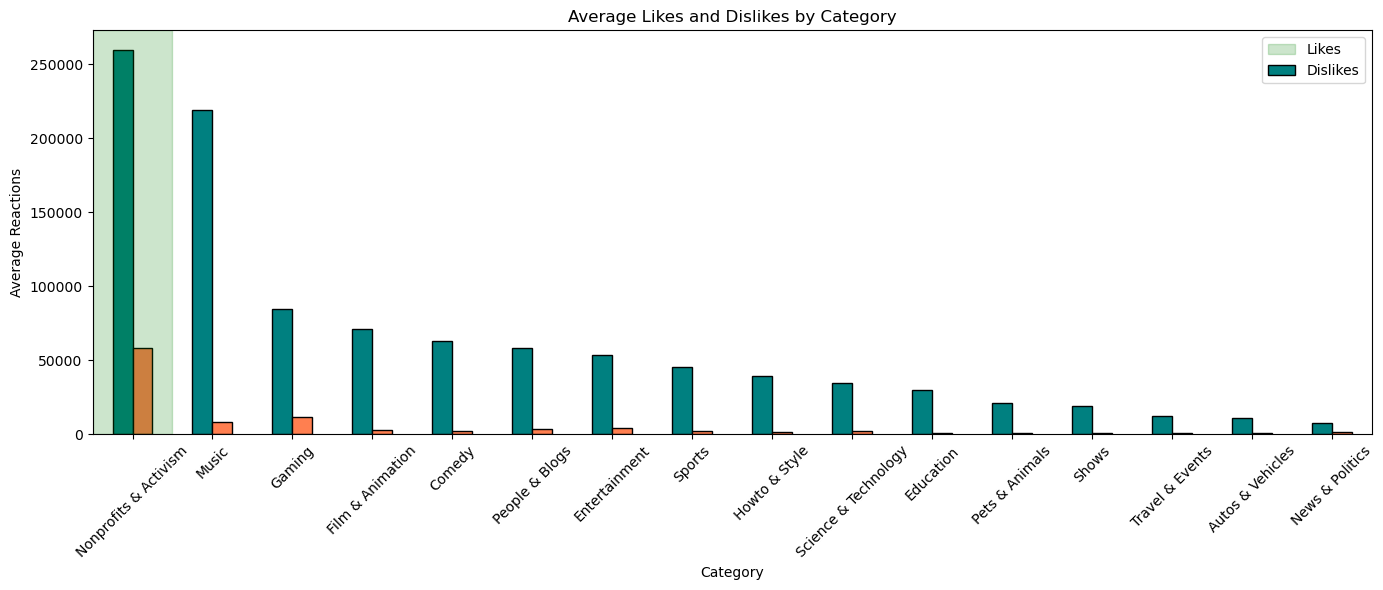

In [63]:
# Reactions per category

category_reactions = (
    us_df.groupby("youtube_category_name")[["likes", "dislikes"]].mean().sort_values("likes", ascending=False)
)

category_reactions.plot(
    kind="bar",
    figsize=(14,6),
    color=["teal", "coral"],
    edgecolor="black"
)

plt.title("Average Likes and Dislikes by Category")
plt.xlabel("Category")
plt.ylabel("Average Reactions")
plt.xticks(rotation=45)
plt.axvspan(-0.5, 0.5, color='green', alpha=0.2)

plt.legend(["Likes", "Dislikes"])

plt.tight_layout()
plt.show()

In [ ]:
us_df.groupby('youtube_category_name')['like_ratio'].mean().sort_values()

youtube_category_name
News & Politics          0.788987
Autos & Vehicles         0.906824
Sports                   0.909812
Entertainment            0.923928
Nonprofits & Activism    0.924172
Travel & Events          0.927572
Film & Animation         0.934847
Gaming                   0.936088
People & Blogs           0.937238
Science & Technology     0.940772
Comedy                   0.954743
Education                0.959604
Howto & Style            0.962523
Music                    0.963989
Shows                    0.967697
Pets & Animals           0.969328
Name: like_ratio, dtype: float64

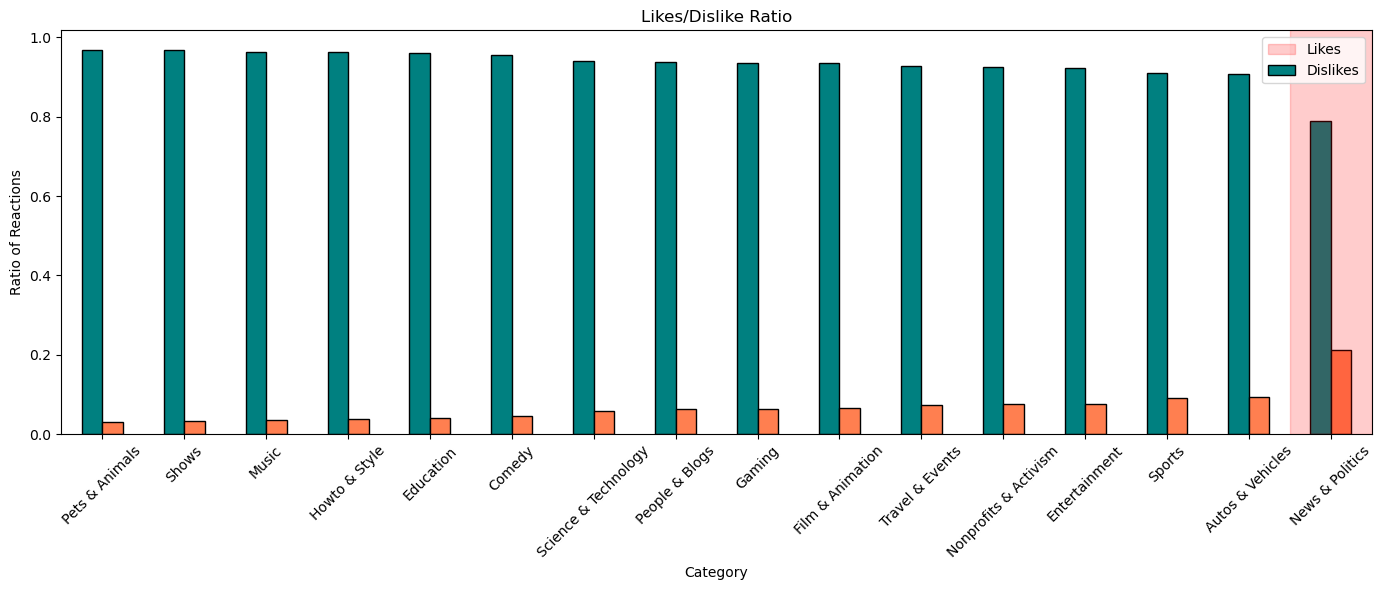

In [ ]:
# Likes/dislike ratio

category_reactions = (
    us_df.groupby("youtube_category_name")[["like_ratio", "dislike_ratio"]].mean().sort_values("like_ratio", ascending=False)
)

category_reactions.plot(
    kind="bar",
    figsize=(14,6),
    color=["teal", "coral"],
    edgecolor="black"
)

plt.title("Likes/Dislike Ratio")
plt.xlabel("Category")
plt.ylabel("Ratio of Reactions")
plt.axvspan(14.5, 15.5, color='red', alpha=0.2)
plt.xticks(rotation=45)

plt.legend(["Likes", "Dislikes"])

plt.tight_layout()
plt.show()